# **Лабораторная работа №3. Разведочный анализ и подготовка данных**

Лабораторная работа №3 посвящена разведочному анализу, позволяющему подготовить имеющийся датасет для решения задач.

**Лабораторная работа №3 является первой частью творческого задания.**

Рекомендуется выполнять лабораторную работу в Google Colab с использованием браузера. Если на вашем компьютере установлена Anaconda, вы можете скачать задание и выполнять его с использованием Anaconda.

**Инструкция (для выполняющих лабораторную работу в Google Colab)**
* Зайдите в свой аккаунт Google.
* Создайте копию этого блокнота. Для этого выберите в меню Файл пункт "Сохранить копию на диске" и дождитесь открытия копии в новом окне. Далее переименуйте блокнот. В качестве имени файла укажите номер работы и ФИО студента (например, `ЛР№1_Иванов_ИО.ipynb`). Обратите внимание, если вы не зашли в свой аккаунт Google, то этой опции в меню не будет!
* Далее работайте со своей копией. Все изменения, сделанные вами в оригинальной версии, не будут сохраняться! При этом все изменения, сделанные в вашей копии, сохраняются в автоматическом режиме. Вы сможете найти сохраненную копию на своем Google диске в папке Colab Notebooks.
* Выполните предложенные задания и покажите работу преподавателю.

**Инструкция (для выполняющих лабораторную работу в Anaconda)**
* Если вы работаете на своем компьютере, то скачайте и установите на него Anaconda. Инструкцию по установке и настройке можно найти в СР№1 в курсе на Sakai. Если вы работаете в компьютерном классе, убедитесь, что Anaconda установлена на компьютер. Если этой программы нет, выполняйте работу в Google Colab (см. инструкцию выше).
* Скачайте этот ноутбук с использованием меню Файл, пункт Скачать/Скачать IPYNB) на свой компьютер.
* Запустите Anaconda и откройте в ней скачанный ноутбук.
* Выполните предложенные задания и покажите работу преподавателю.

**Задание 1.** Пользуясь открытыми источниками, подберите набор данных для выполнения лабораторной работы. Набор данных должен соответствовать следующим критериям:
- количество записей (строк) не менее 1000
- количество признаков (столбцов) не менее 10
- в наборе данных имеются пропуски
- в наборе данных выделена целевая метка, либо целевой меткой можно сделать один из признаков
- набор данных содержит разные типы признаков (не только числовые)  
  
В качестве источников можно воспользоваться следующими ресурсами:
- [kaggle.com](kaggle.com)
- [archive.ics.uci.edu](archive.ics.uci.edu)
- https://habr.com/ru/companies/edison/articles/480408/
- https://habr.com/ru/articles/452392/
- https://habr.com/ru/articles/684580/

Также вы можете использовать свои источники, не нарушающие законов РФ.





Задание 1. Информация о наборе данных
Название датасета: Video Game Sales with Ratings
Ссылка на источник: https://www.kaggle.com/rush4ratio/video-game-sales-with-ratings
Описание датасета: Данные о продажах видеоигр по всему миру с 1980 по 2016 год, включая информацию о платформе, жанре, годе выпуска, оценках критиков и пользователей, рейтинге ESRB, а также региональных (NA_Sales, EU_Sales и др.) и глобальных продажах (в миллионах копий). Используется для анализа факторов, влияющих на коммерческий успех видеоигр.

**Задание 2.**  Загрузите набор данных для первичного просмотра. Выведите голову таблицы, чтобы убедиться что все отображается корректно. Выведите информацию о наборе (`info`). Выведите уникальные значения по каждому столбцу.

In [13]:
# Напишите здесь решение задания 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка
df = pd.read_csv("Video_Games_Sales_as_at_22_Dec_2016.csv")

# Просмотр
print("=== Первые 5 строк ===")
print(df.head())

print("\n=== Общая информация ===")
print(df.info())

print("\n=== Уникальные значения в каждом столбце (первые 10) ===")
for col in df.columns:
    uniq = df[col].dropna().unique()
    print(
        f"{col} ({len(uniq)} уникальных): {uniq[:10]}{'...' if len(uniq) > 10 else ''}"
    )

=== Первые 5 строк ===
                       Name Platform  Year_of_Release         Genre Publisher  \
0                Wii Sports      Wii           2006.0        Sports  Nintendo   
1         Super Mario Bros.      NES           1985.0      Platform  Nintendo   
2            Mario Kart Wii      Wii           2008.0        Racing  Nintendo   
3         Wii Sports Resort      Wii           2009.0        Sports  Nintendo   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  Critic_Score  \
0     41.36     28.96      3.77         8.45         82.53          76.0   
1     29.08      3.58      6.81         0.77         40.24           NaN   
2     15.68     12.76      3.79         3.29         35.52          82.0   
3     15.61     10.93      3.28         2.95         32.77          80.0   
4     11.27      8.89     10.22         1.00         31.37           NaN   

   Critic_Count User_Score  User_

**Задание 3.** Пользуясь информацией, полученной при выполнении задания 2, сделайте описание набора данных.



### Описание параметров

| НАЗВАНИЕ           | ТИП ДАННЫХ                  | ОПИСАНИЕ |
|--------------------|-----------------------------|---------|
| `Name`             | `object`                    | Название игры |
| `Platform`         | `object`                    | Игровая платформа (например, PS4, X360, PC) |
| `Year_of_Release`  | `float` → `int`             | Год выпуска (есть пропуски) |
| `Genre`            | `object`                    | Жанр (Action, Sports, Shooter и др.) |
| `Publisher`        | `object`                    | Издатель |
| `NA_Sales`         | `float`                     | Продажи в Северной Америке (млн копий) |
| `EU_Sales`         | `float`                     | Продажи в Европе (млн копий) |
| `JP_Sales`         | `float`                     | Продажи в Японии (млн копий) |
| `Other_Sales`      | `float`                     | Продажи в остальном мире (млн копий) |
| `Global_Sales`     | `float`                     | Общие продажи (млн копий) — возможная целевая переменная |
| `Critic_Score`     | `float`                     | Средняя оценка критиков (0–100, много пропусков) |
| `Critic_Count`     | `float`                     | Количество критиков |
| `User_Score`       | `object` → `float`          | Средняя оценка пользователей (0–10; строка `"tbd"` для неоценённых) |
| `User_Count`       | `float`                     | Количество пользователей, оставивших оценку |
| `Developer`        | `object`                    | Разработчик (много пропусков) |
| `Rating`           | `object`                    | Возрастной рейтинг ESRB (E, T, M и др.) |

> **Примечание:**  
> - Исходное количество записей: **16 598**  
> - После удаления строк с пропусками в ключевых столбцах: **6 825**

**Задание 4.** Удалите дубликаты из вашего набора данных. Обработайте возможные пропущенные значения.

In [14]:
# Напишите здесь решение задания 4
print("Дубликатов до:", df.duplicated().sum())
df = df.drop_duplicates()
print("Дубликатов после:", df.duplicated().sum())

# Анализ пропусков
print("\nПропуски по столбцам:")
print(df.isnull().sum())

# Подготовка: фильтрация по обязательным столбцам (как в ЛР2)
required_cols = [
    "Name",
    "Platform",
    "Year_of_Release",
    "Genre",
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Rating",
]

df_clean = df[required_cols].copy()

# Обработка User_Score: 'tbd' → NaN → float
df_clean["User_Score"] = pd.to_numeric(df_clean["User_Score"], errors="coerce")

# Удаление строк с пропусками в этих столбцах
df_clean = df_clean.dropna()
df_clean["Year_of_Release"] = df_clean["Year_of_Release"].astype("int64")
df_clean["User_Count"] = df_clean["User_Count"].astype("int64")
df_clean["Critic_Count"] = df_clean["Critic_Count"].astype("int64")

print("\nРазмер после очистки:", df_clean.shape)  # Должно быть ~6825

Дубликатов до: 0
Дубликатов после: 0

Пропуски по столбцам:
Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

Размер после очистки: (6826, 14)


**Задание 5**. Произведите анализ распределений переменных. Интерпретируйте полученные результаты.

# Напишите здесь решение задания 5


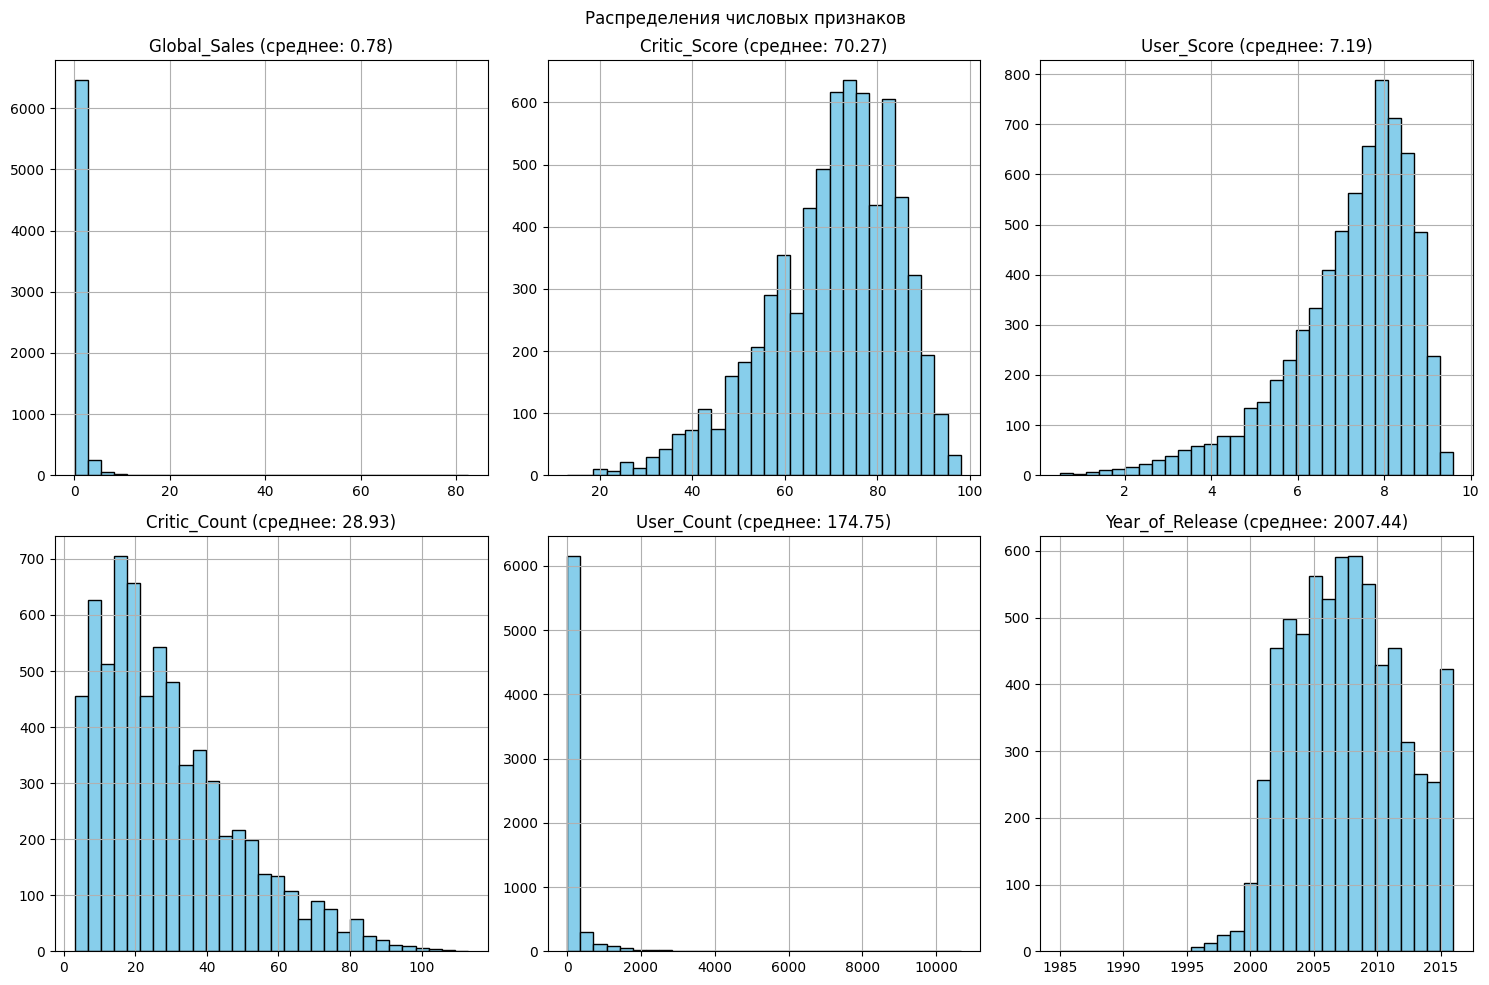

In [15]:
# Числовые признаки
num_cols = [
    "Global_Sales",
    "Critic_Score",
    "User_Score",
    "Critic_Count",
    "User_Count",
    "Year_of_Release",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=30, color="skyblue", edgecolor="black")
    axes[i].set_title(f"{col} (среднее: {df_clean[col].mean():.2f})")
    axes[i].grid(True)

plt.suptitle("Распределения числовых признаков")
plt.tight_layout()
plt.show()

# Интерпретация (пишем в Markdown ниже)

**Интерпретируйте полученные результатыу. Для редактирования ячейки нажмите на нее дважды**
Интерпретация полученных результатов: 

Global_Sales сильно смещено влево: большинство игр продаются менее 1 млн копий, есть редкие хиты (>10 млн) — высокая асимметрия, требует лог-преобразования для регрессии.
Critic_Score и User_Score приблизительно нормальны (70–80 баллов — мода), что говорит о реалистичности оценок.
Critic_Count и User_Count также смещены: большинство игр имеют мало отзывов, хиты — тысячи.
Year_of_Release показывает пик в 2005–2010 гг. — «золотая эра» консолей PS3/X360

**Задание 6.** Проведите обработку выбросов и аномалий.

In [16]:
# Напишите здесь решение задания 6
Q1 = df_clean["Global_Sales"].quantile(0.25)
Q3 = df_clean["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean["Global_Sales"] < lower_bound) | (df_clean["Global_Sales"] > upper_bound)
]
print(f"Выбросов по IQR в Global_Sales: {len(outliers)} из {len(df_clean)}")

# Опционально: ограничим верхний хвост (игры > 5 млн — 1% данных)
threshold = df_clean["Global_Sales"].quantile(0.99)
print(f"99-й перцентиль Global_Sales: {threshold:.2f} млн")

# Создаём копию без экстремальных выбросов (если нужно для регрессии)
df_no_extreme = df_clean[df_clean["Global_Sales"] <= threshold].copy()
print("Размер после удаления экстремальных выбросов:", df_no_extreme.shape)

Выбросов по IQR в Global_Sales: 680 из 6826
99-й перцентиль Global_Sales: 7.17 млн
Размер после удаления экстремальных выбросов: (6757, 14)


    Ч

**Задание 7.** Выполните нормализацию или стандартизацию данных, если это необходимо.

In [17]:
# Напишите здесь решение задания 7
from sklearn.preprocessing import StandardScaler

# Выберем числовые признаки для стандартизации
scale_cols = [
    "Critic_Score",
    "User_Score",
    "Critic_Count",
    "User_Count",
    "Year_of_Release",
]

scaler = StandardScaler()
df_clean_scaled = df_clean.copy()
df_clean_scaled[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print("Пример стандартизированных данных:")
print(df_clean_scaled[scale_cols].head())

Пример стандартизированных данных:
   Critic_Score  User_Score  Critic_Count  User_Count  Year_of_Release
0      0.413235    0.565719      1.148143    0.250707        -0.341332
2      0.845842    0.773962      2.292704    0.909603         0.133631
3      0.701640    0.565719      2.292704    0.029373         0.371113
6      1.350550    0.912791      1.876500    0.436288        -0.341332
7     -0.884586   -0.406084      0.627888   -0.077889        -0.341332


**Задание 8.** Постройте матрицу корреляции параметров датасета.

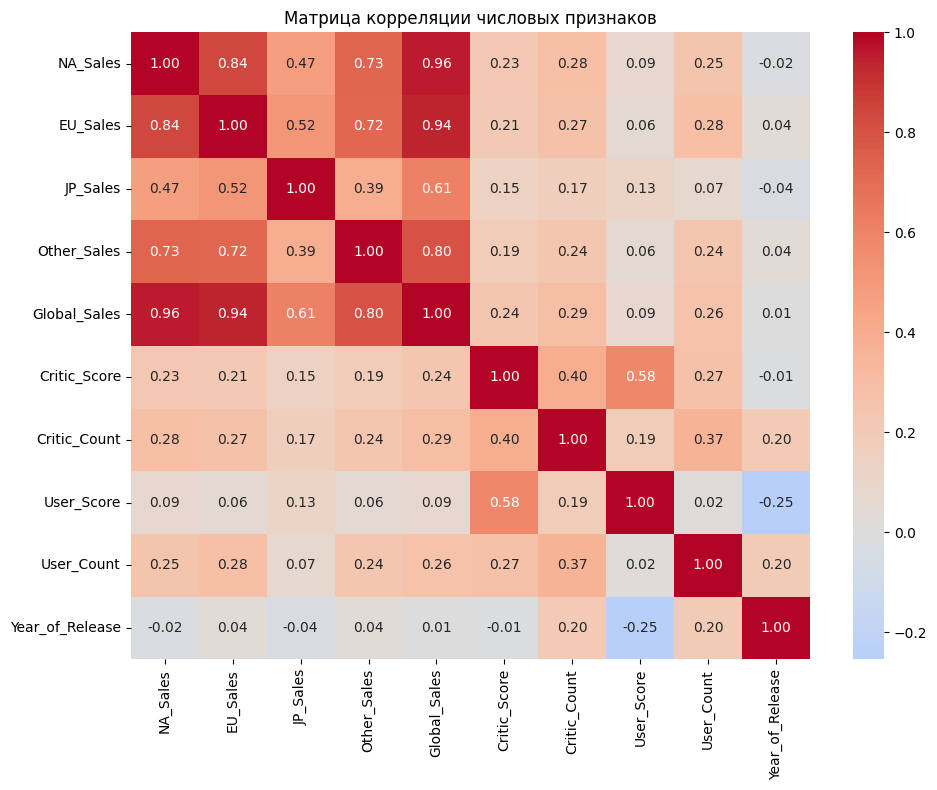

In [18]:
# Напишите здесь решение задания 8
# Числовые столбцы для корреляции
corr_cols = [
    "NA_Sales",
    "EU_Sales",
    "JP_Sales",
    "Other_Sales",
    "Global_Sales",
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Year_of_Release",
]

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляции числовых признаков")
plt.tight_layout()
plt.show()

**Сохраните этот ноутбук и датасет! Они потребуются для выполнения творческого задания!**